# Feature Engineering — Fussball Vorhersagen
Version 8: Features maximal bis Vorsaison, is_promoted nur bis Spieltag 5.

In [2]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt

DB_CONFIG = {
    'host': 'localhost',
    'port': 5432,
    'dbname': 'fussball',
    'user': 'fussball',
    'password': 'fussball_pw'
}

conn = psycopg2.connect(**DB_CONFIG)
print('Verbindung erfolgreich!')

Verbindung erfolgreich!


## 1. Alle Daten laden

In [3]:
query = """
    SELECT 
        m.id,
        m.utc_date,
        m.matchday,
        m.season_id,
        s.start_date AS season_start,
        m.home_team_id,
        m.away_team_id,
        t1.name AS home_team,
        t2.name AS away_team,
        m.home_score_fulltime,
        m.away_score_fulltime,
        m.winner
    FROM matches m
    JOIN teams t1 ON m.home_team_id = t1.id
    JOIN teams t2 ON m.away_team_id = t2.id
    JOIN seasons s ON m.season_id = s.id
    WHERE m.status = 'FINISHED'
    ORDER BY m.utc_date ASC
"""

df = pd.read_sql(query, conn)
df['utc_date'] = pd.to_datetime(df['utc_date'])
df['season_start'] = pd.to_datetime(df['season_start'])
df['season'] = df['season_start'].dt.year

print(f'Spiele total geladen: {len(df)}')
print(f'Saisons: {df["season"].unique()}')
df.head()

Spiele total geladen: 917
Saisons: [2023 2024 2025]


C:\Users\Nico\AppData\Local\Temp\ipykernel_7084\2377651085.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,utc_date,matchday,season_id,season_start,home_team_id,away_team_id,home_team,away_team,home_score_fulltime,away_score_fulltime,winner,season
0,441789,2023-08-18 18:30:00,1,1592,2023-08-18,12,5,SV Werder Bremen,FC Bayern München,0,4,AWAY_TEAM,2023
1,441792,2023-08-19 13:30:00,1,1592,2023-08-18,3,721,Bayer 04 Leverkusen,RB Leipzig,3,2,HOME_TEAM,2023
2,441794,2023-08-19 13:30:00,1,1592,2023-08-18,11,44,VfL Wolfsburg,1. FC Heidenheim 1846,2,0,HOME_TEAM,2023
3,441795,2023-08-19 13:30:00,1,1592,2023-08-18,2,17,TSG 1899 Hoffenheim,SC Freiburg,1,2,AWAY_TEAM,2023
4,441796,2023-08-19 13:30:00,1,1592,2023-08-18,16,18,FC Augsburg,Borussia Mönchengladbach,4,4,DRAW,2023


## 2. Hilfsfunktion: Vorsaison ID

In [4]:
# Vorsaison IDs vorberechnen für Performance
season_ids = sorted(df['season_id'].unique())
prev_season_map = {}
for i, sid in enumerate(season_ids):
    if i == 0:
        prev_season_map[sid] = sid  # erste Saison: keine Vorsaison
    else:
        prev_season_map[sid] = season_ids[i - 1]

print('Saison → Vorsaison Mapping:')
for k, v in prev_season_map.items():
    print(f'  {k} → {v}')

Saison → Vorsaison Mapping:
  1592 → 1592
  2308 → 1592
  2414 → 2308


## 3. Feature-Funktionen

In [ ]:
def get_prev_season_id(season_id):
    """Gibt die direkte Vorsaison ID zurück."""
    return prev_season_map.get(season_id, season_id)



#
def get_form(df, team_id, date, season_id, n=5):
    """Punkte der letzten n Spiele — maximal bis Vorsaison."""
    prev_sid = get_prev_season_id(season_id)
    spiele = df[
        ((df['home_team_id'] == team_id) | (df['away_team_id'] == team_id)) &
        (df['utc_date'] < date) &
        (df['season_id'] >= prev_sid)
    ].tail(n)
    punkte = 0
    for _, s in spiele.iterrows():
        if s['home_team_id'] == team_id:
            if s['winner'] == 'HOME_TEAM': punkte += 3
            elif s['winner'] == 'DRAW': punkte += 1
        else:
            if s['winner'] == 'AWAY_TEAM': punkte += 3
            elif s['winner'] == 'DRAW': punkte += 1
    return punkte


def get_home_form(df, team_id, date, season_id, n=5):
    """Punkte der letzten n Heimspiele — maximal bis Vorsaison."""
    prev_sid = get_prev_season_id(season_id)
    spiele = df[
        (df['home_team_id'] == team_id) &
        (df['utc_date'] < date) &
        (df['season_id'] >= prev_sid)
    ].tail(n)
    punkte = 0
    for _, s in spiele.iterrows():
        if s['winner'] == 'HOME_TEAM': punkte += 3
        elif s['winner'] == 'DRAW': punkte += 1
    return punkte


def get_away_form(df, team_id, date, season_id, n=5):
    """Punkte der letzten n Auswärtsspiele — maximal bis Vorsaison."""
    prev_sid = get_prev_season_id(season_id)
    spiele = df[
        (df['away_team_id'] == team_id) &
        (df['utc_date'] < date) &
        (df['season_id'] >= prev_sid)
    ].tail(n)
    punkte = 0
    for _, s in spiele.iterrows():
        if s['winner'] == 'AWAY_TEAM': punkte += 3
        elif s['winner'] == 'DRAW': punkte += 1
    return punkte


def get_heimquote(df, team_id, date, season_id, n=12):
    """Heimsiegquote der letzten n Heimspiele — maximal bis Vorsaison."""
    prev_sid = get_prev_season_id(season_id)
    spiele = df[
        (df['home_team_id'] == team_id) &
        (df['utc_date'] < date) &
        (df['season_id'] >= prev_sid)
    ].tail(n)
    if len(spiele) == 0:
        return 0.5
    return (spiele['winner'] == 'HOME_TEAM').mean()


def get_win_streak(df, team_id, date, season_id):
    """Aktuelle Siegesserie — maximal bis Vorsaison."""
    prev_sid = get_prev_season_id(season_id)
    spiele = df[
        ((df['home_team_id'] == team_id) | (df['away_team_id'] == team_id)) &
        (df['utc_date'] < date) &
        (df['season_id'] >= prev_sid)
    ].sort_values('utc_date', ascending=False)
    streak = 0
    for _, s in spiele.iterrows():
        gewonnen = (
            (s['home_team_id'] == team_id and s['winner'] == 'HOME_TEAM') or
            (s['away_team_id'] == team_id and s['winner'] == 'AWAY_TEAM')
        )
        if gewonnen: streak += 1
        else: break
    return streak


def get_goal_diff(df, team_id, date, season_id, n=5):
    """Durchschnittliche Tordifferenz — maximal bis Vorsaison."""
    prev_sid = get_prev_season_id(season_id)
    spiele = df[
        ((df['home_team_id'] == team_id) | (df['away_team_id'] == team_id)) &
        (df['utc_date'] < date) &
        (df['season_id'] >= prev_sid)
    ].tail(n)
    if len(spiele) == 0:
        return 0
    diff = 0
    for _, s in spiele.iterrows():
        if s['home_team_id'] == team_id:
            diff += s['home_score_fulltime'] - s['away_score_fulltime']
        else:
            diff += s['away_score_fulltime'] - s['home_score_fulltime']
    return diff / len(spiele)


def is_promoted(df, team_id, season_id, matchday):
    """
    Gibt 1 zurück wenn:
    - Team hat in der direkten Vorsaison nicht gespielt (echter Aufsteiger)
    - UND es ist noch Spieltag 1-5 (danach genug echte Daten)
    """
    if matchday > 5:
        return 0

    prev_sid = get_prev_season_id(season_id)
    if prev_sid == season_id:  # erste Saison in DB
        return 0

    vorherige = df[
        ((df['home_team_id'] == team_id) | (df['away_team_id'] == team_id)) &
        (df['season_id'] == prev_sid)
    ]
    return 1 if len(vorherige) == 0 else 0


print('Funktionen definiert!')

Funktionen definiert!


## 4. Features berechnen

In [6]:
print('Berechne Features — dauert etwas...')

features = []
for i, (_, row) in enumerate(df.iterrows()):
    if i % 100 == 0:
        print(f'  {i}/{len(df)} verarbeitet...')

    sid = row['season_id']
    hid = row['home_team_id']
    aid = row['away_team_id']
    dat = row['utc_date']
    md  = row['matchday']

    home_form      = get_form(df, hid, dat, sid)
    away_form      = get_form(df, aid, dat, sid)
    home_form_home = get_home_form(df, hid, dat, sid)
    away_form_away = get_away_form(df, aid, dat, sid)
    heimquote      = get_heimquote(df, hid, dat, sid)
    home_streak    = get_win_streak(df, hid, dat, sid)
    away_streak    = get_win_streak(df, aid, dat, sid)
    home_goal_diff = get_goal_diff(df, hid, dat, sid)
    away_goal_diff = get_goal_diff(df, aid, dat, sid)
    home_promoted  = is_promoted(df, hid, sid, md)
    away_promoted  = is_promoted(df, aid, sid, md)

    features.append({
        'match_id':         row['id'],
        'utc_date':         dat,
        'matchday':         md,
        'season_id':        sid,
        'season':           row['season'],
        'home_team':        row['home_team'],
        'away_team':        row['away_team'],
        'home_form':        home_form,
        'away_form':        away_form,
        'home_form_home':   home_form_home,
        'away_form_away':   away_form_away,
        'heimquote':        heimquote,
        'home_streak':      home_streak,
        'away_streak':      away_streak,
        'home_goal_diff':   home_goal_diff,
        'away_goal_diff':   away_goal_diff,
        'is_promoted_home': home_promoted,
        'is_promoted_away': away_promoted,
        'winner':           row['winner']
    })

df_features = pd.DataFrame(features)
print(f'\nFertig! {len(df_features)} Spiele total')

Berechne Features — dauert etwas...
  0/917 verarbeitet...
  100/917 verarbeitet...
  200/917 verarbeitet...
  300/917 verarbeitet...
  400/917 verarbeitet...
  500/917 verarbeitet...
  600/917 verarbeitet...
  700/917 verarbeitet...
  800/917 verarbeitet...
  900/917 verarbeitet...

Fertig! 917 Spiele total


## 5. Bereinigung — nur 2024 + 2025

In [7]:
vorher = len(df_features)

df_features = df_features[df_features['season'] >= 2024]
print(f'Nach Saison-Filter: {len(df_features)} Spiele')

df_features = df_features[
    ~((df_features['home_form'] == 0) & (df_features['away_form'] == 0))
]
print(f'Nach 0-0 Bereinigung: {len(df_features)} Spiele')

df_features = df_features[
    ~((df_features['home_form_home'] == 0) & (df_features['away_form_away'] == 0))
]
print(f'Nach Heim/Auswärts Bereinigung: {len(df_features)} Spiele')
print(f'Total rausgelöscht: {vorher - len(df_features)}')
print(f'\nAufsteiger Heimteam: {df_features["is_promoted_home"].sum()}')
print(f'Aufsteiger Auswärtsteam: {df_features["is_promoted_away"].sum()}')

Nach Saison-Filter: 611 Spiele
Nach 0-0 Bereinigung: 610 Spiele
Nach Heim/Auswärts Bereinigung: 610 Spiele
Total rausgelöscht: 307

Aufsteiger Heimteam: 9
Aufsteiger Auswärtsteam: 10


## 6. Features anschauen

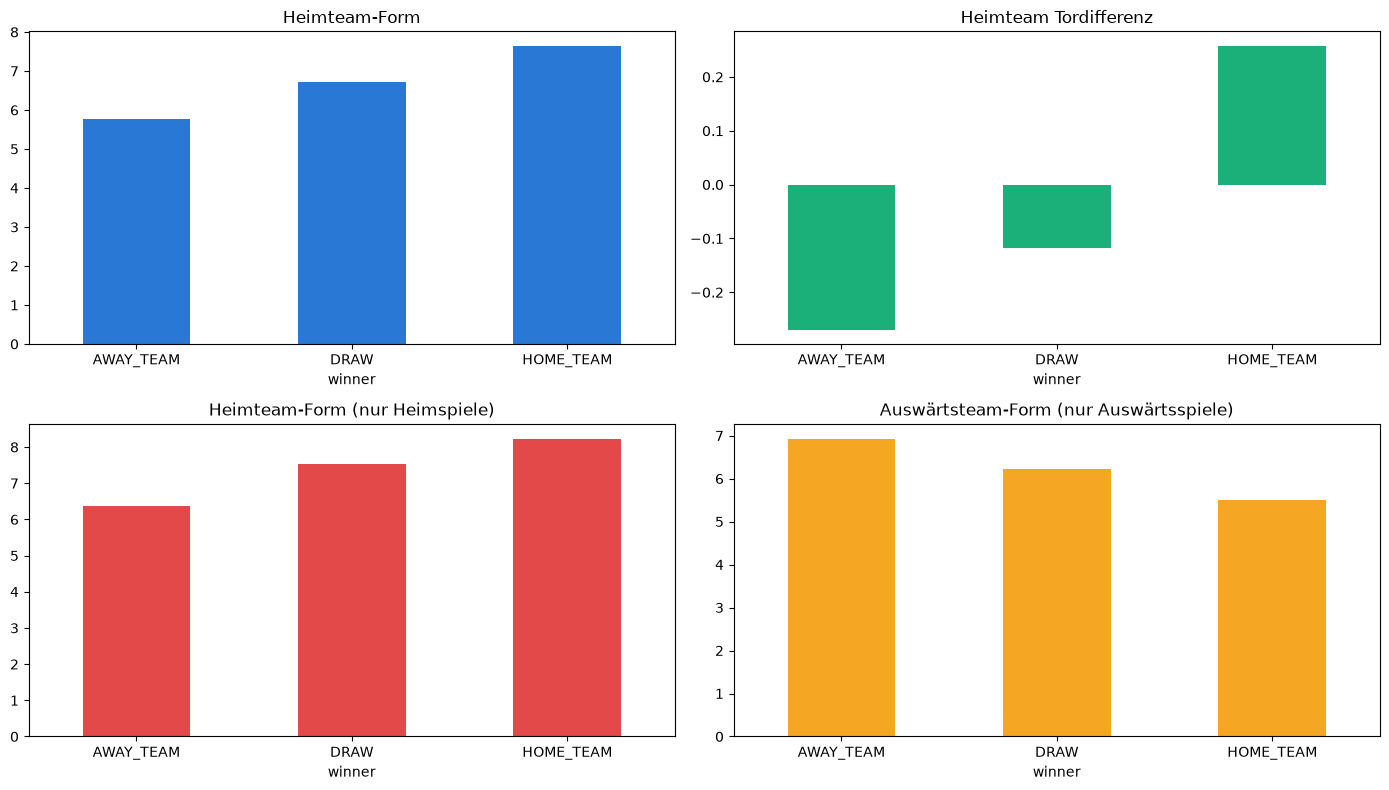

Ergebnis-Verteilung:
winner
HOME_TEAM    252
AWAY_TEAM    207
DRAW         151
Name: count, dtype: int64


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

df_features.groupby('winner')['home_form'].mean().plot(kind='bar', ax=axes[0,0], color='#2a78d6')
axes[0,0].set_title('Heimteam-Form')
axes[0,0].tick_params(rotation=0)

df_features.groupby('winner')['home_goal_diff'].mean().plot(kind='bar', ax=axes[0,1], color='#1baf7a')
axes[0,1].set_title('Heimteam Tordifferenz')
axes[0,1].tick_params(rotation=0)

df_features.groupby('winner')['home_form_home'].mean().plot(kind='bar', ax=axes[1,0], color='#e34948')
axes[1,0].set_title('Heimteam-Form (nur Heimspiele)')
axes[1,0].tick_params(rotation=0)

df_features.groupby('winner')['away_form_away'].mean().plot(kind='bar', ax=axes[1,1], color='#f5a623')
axes[1,1].set_title('Auswärtsteam-Form (nur Auswärtsspiele)')
axes[1,1].tick_params(rotation=0)

plt.tight_layout()
plt.show()

print('Ergebnis-Verteilung:')
print(df_features['winner'].value_counts())

## 7. Speichern

In [10]:
df_features.to_csv('data/features.csv', index=False, encoding='utf-8')
print(f'Features gespeichert: {len(df_features)} Spiele')
print(f'Saisons: {df_features["season"].unique()}')
print(f'Spalten: {df_features.columns.tolist()}')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df_features


Features gespeichert: 610 Spiele
Saisons: [2024 2025]
Spalten: ['match_id', 'utc_date', 'matchday', 'season_id', 'season', 'home_team', 'away_team', 'home_form', 'away_form', 'home_form_home', 'away_form_away', 'heimquote', 'home_streak', 'away_streak', 'home_goal_diff', 'away_goal_diff', 'is_promoted_home', 'is_promoted_away', 'winner']


,match_id,utc_date,matchday,season_id,season,home_team,away_team,home_form,away_form,home_form_home,away_form_away,heimquote,home_streak,away_streak,home_goal_diff,away_goal_diff,is_promoted_home,is_promoted_away,winner
306,502371,2024-08-23 18:30:00,1,2308,2024,Borussia Mönchengladbach,Bayer 04 Leverkusen,3,11,3,13,0.333333,0,3,-1.000000,2.000000,0,0,AWAY_TEAM
307,502372,2024-08-24 13:30:00,1,2308,2024,RB Leipzig,VfL Bochum 1848,9,6,11,3,0.666667,0,0,0.800000,-1.400000,0,0,HOME_TEAM
308,502374,2024-08-24 13:30:00,1,2308,2024,TSG 1899 Hoffenheim,Holstein Kiel,10,0,10,0,0.416667,2,0,1.600000,0.000000,0,1,HOME_TEAM
309,502375,2024-08-24 13:30:00,1,2308,2024,SC Freiburg,VfB Stuttgart,3,10,2,10,0.166667,0,3,-0.400000,1.200000,0,0,HOME_TEAM
310,502376,2024-08-24 13:30:00,1,2308,2024,FC Augsburg,SV Werder Bremen,0,11,7,5,0.333333,0,1,-2.200000,1.400000,0,0,DRAW
311,502378,2024-08-24 13:30:00,1,2308,2024,1. FSV Mainz 05,1. FC Union Berlin,9,4,13,2,0.416667,2,1,1.000000,-1.000000,0,0,DRAW
312,502373,2024-08-24 16:30:00,1,2308,2024,Borussia Dortmund,Eintracht Frankfurt,7,5,10,4,0.500000,1,0,0.400000,-0.600000,0,0,HOME_TEAM
313,502377,2024-08-25 13:30:00,1,2308,2024,VfL Wolfsburg,FC Bayern München,9,9,6,6,0.250000,0,0,0.200000,0.600000,0,0,AWAY_TEAM
314,502379,2024-08-25 15:30:00,1,2308,2024,FC St. Pauli 1910,1. FC Heidenheim 1846,0,8,0,6,0.500000,0,1,0.000000,0.600000,1,0,AWAY_TEAM
315,502386,2024-08-30 18:30:00,2,2308,2024,1. FC Union Berlin,FC St. Pauli 1910,5,0,6,0,0.500000,0,0,-0.200000,-2.000000,0,1,HOME_TEAM
